Transfer Learning & Fine-Tuning a CNN (VGG16) - Hands-on Notebook

Dataset: the classic **flower_photos** dataset (5 classes, ~3700 images),

Block 1 - Imports

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


Block 2 - Download the dataset


In [22]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive_path = keras.utils.get_file("flower_photos.tgz", origin=dataset_url, extract=True)

extract_root = os.path.dirname(archive_path)

# Walk the extracted tree to find the folder that actually contains the class subfolders
expected_classes = {"daisy", "dandelion", "roses", "sunflowers", "tulips"}
data_dir = None
for root, dirs, files in os.walk(extract_root):
    if expected_classes.issubset(set(dirs)):
        data_dir = root
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate flower_photos class folders under: " + extract_root)

print("Dataset found at:", data_dir)
print("Classes found:", [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

Dataset found at: C:\Users\kokil\.keras\datasets\flower_photos\flower_photos
Classes found: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


Block 3 - Data generators (train/validation split)

In [23]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# validation should NOT be augmented, only preprocessed
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

NUM_CLASSES = train_gen.num_classes
class_labels = list(train_gen.class_indices.keys())
print("Number of classes:", NUM_CLASSES)
print("Class labels:", class_labels)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Number of classes: 5
Class labels: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


Block 4 - Load VGG16 base (pretrained on ImageNet)

In [24]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

 Block 5  - Inspect layers

In [25]:
for layer in base_model.layers:
    print(f"{layer.name:<20} | Type: {type(layer).__name__:<20} | Trainable: {layer.trainable}")


input_layer_1        | Type: InputLayer           | Trainable: True
block1_conv1         | Type: Conv2D               | Trainable: True
block1_conv2         | Type: Conv2D               | Trainable: True
block1_pool          | Type: MaxPooling2D         | Trainable: True
block2_conv1         | Type: Conv2D               | Trainable: True
block2_conv2         | Type: Conv2D               | Trainable: True
block2_pool          | Type: MaxPooling2D         | Trainable: True
block3_conv1         | Type: Conv2D               | Trainable: True
block3_conv2         | Type: Conv2D               | Trainable: True
block3_conv3         | Type: Conv2D               | Trainable: True
block3_pool          | Type: MaxPooling2D         | Trainable: True
block4_conv1         | Type: Conv2D               | Trainable: True
block4_conv2         | Type: Conv2D               | Trainable: True
block4_conv3         | Type: Conv2D               | Trainable: True
block4_pool          | Type: MaxPooling2D       

Block 6 - Type 1 Fine-Tuning: Feature Extraction


In [26]:
for layer in base_model.layers:
    layer.trainable = False

x = layers.Flatten()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_stage1 = Model(inputs=base_model.input, outputs=output)

model_stage1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_stage1.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,757 (80.64 MB)

 Trainable params: 6,424,069 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Block 7 - Train Stage 1 (frozen base)


In [28]:
EPOCHS_STAGE1 = 5

callbacks_stage1 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_stage1.keras', monitor='val_accuracy', save_best_only=True)
]

history_stage1 = model_stage1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_stage1
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 776s 8s/step - accuracy: 0.6274 - loss: 5.1668 - val_accuracy: 0.7893 - val_loss: 1.5532
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 763s 8s/step - accuracy: 0.7329 - loss: 1.6181 - val_accuracy: 0.8071 - val_loss: 1.0299
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1242s 14s/step - accuracy: 0.7618 - loss: 0.9941 - val_accuracy: 0.8030 - val_loss: 0.8459
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 913s 10s/step - accuracy: 0.7782 - loss: 0.7576 - val_accuracy: 0.8345 - val_loss: 0.6729
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 798s 9s/step - accuracy: 0.8135 - loss: 0.5880 - val_accuracy: 0.8317 - val_loss: 0.6624


Block 8 - Plot Stage 1 accuracy & loss

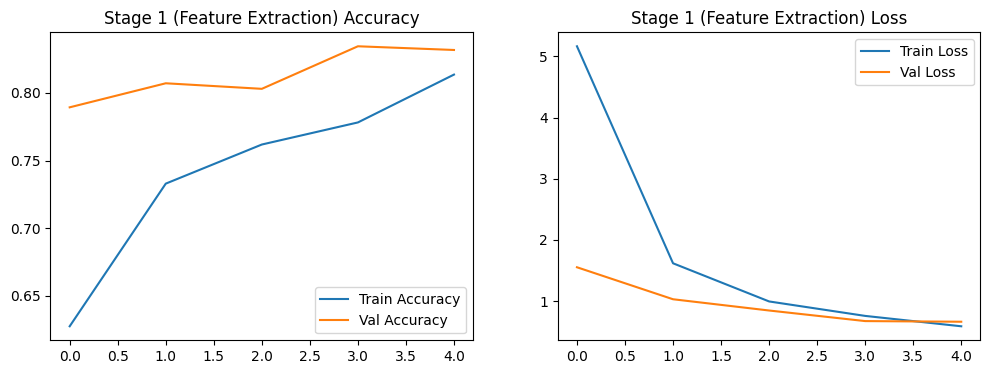

In [29]:
def plot_history(history, title_prefix=""):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend()
    plt.title(f'{title_prefix} Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title(f'{title_prefix} Loss')

    plt.show()

plot_history(history_stage1, title_prefix="Stage 1 (Feature Extraction)")


Block 9 - Type 2 Fine-Tuning: Unfreeze top conv block

In [30]:
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

for layer in base_model.layers:
    print(f"{layer.name:<20} | Trainable: {layer.trainable}")


input_layer_1        | Trainable: False
block1_conv1         | Trainable: False
block1_conv2         | Trainable: False
block1_pool          | Trainable: False
block2_conv1         | Trainable: False
block2_conv2         | Trainable: False
block2_pool          | Trainable: False
block3_conv1         | Trainable: False
block3_conv2         | Trainable: False
block3_conv3         | Trainable: False
block3_pool          | Trainable: False
block4_conv1         | Trainable: False
block4_conv2         | Trainable: False
block4_conv3         | Trainable: False
block4_pool          | Trainable: False
block5_conv1         | Trainable: True
block5_conv2         | Trainable: True
block5_conv3         | Trainable: True
block5_pool          | Trainable: True


Block 10 - Recompile with a low learning rate

In [31]:
model_stage1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Block 11 - Train Stage 2 (fine-tuning)

In [32]:
EPOCHS_STAGE2 = 5

callbacks_stage2 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_stage2.keras', monitor='val_accuracy', save_best_only=True)
]

history_stage2 = model_stage1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 674s 7s/step - accuracy: 0.8370 - loss: 0.5287 - val_accuracy: 0.8591 - val_loss: 0.6441
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1195s 13s/step - accuracy: 0.8598 - loss: 0.4778 - val_accuracy: 0.8632 - val_loss: 0.5988
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 813s 9s/step - accuracy: 0.8700 - loss: 0.4239 - val_accuracy: 0.8755 - val_loss: 0.5786
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 827s 9s/step - accuracy: 0.8758 - loss: 0.3811 - val_accuracy: 0.8837 - val_loss: 0.5571
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 947s 10s/step - accuracy: 0.8949 - loss: 0.3214 - val_accuracy: 0.8851 - val_loss: 0.5153


Block 12 - Plot Stage 2 accuracy & loss

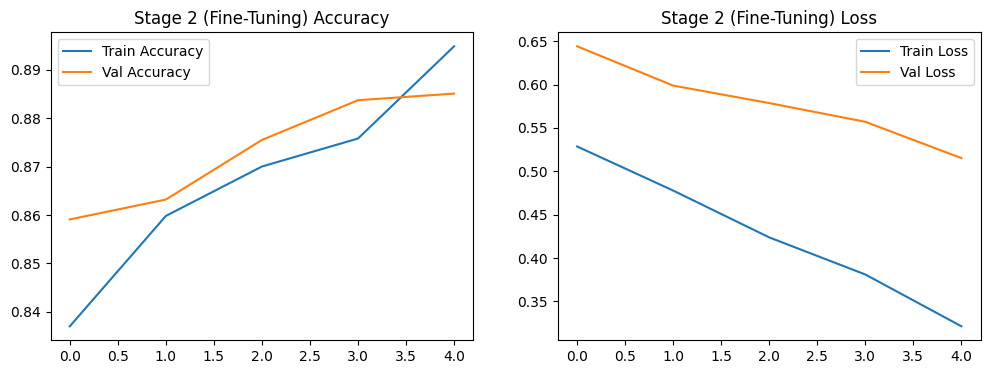

In [33]:
plot_history(history_stage2, title_prefix="Stage 2 (Fine-Tuning)")


13 - Predict on a single new image

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


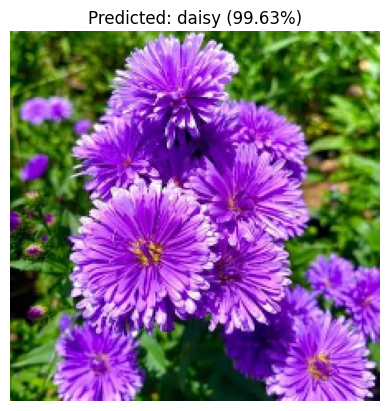

('daisy', np.float32(99.63339))

In [34]:
from tensorflow.keras.preprocessing import image as kimage

def predict_image(img_path):
    if not os.path.exists(img_path):
        print(f"File not found: {img_path}")
        return None, None

    img = kimage.load_img(img_path, target_size=IMG_SIZE)
    img_array = kimage.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model_stage1.predict(img_array)
    predicted_class = class_labels[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.show()

    return predicted_class, confidence

# Grab a real sample from val_gen instead of a hardcoded missing file
sample_batch, _ = next(val_gen)
sample_class = class_labels[0]
sample_dir = os.path.join(data_dir, sample_class)
sample_img_path = os.path.join(sample_dir, os.listdir(sample_dir)[0])
predict_image(r"E:\LLM TUTROIAL\WEEK1\test1.png")